# Hate Speech Text Classification
Herald College Kathmandu | 6CS012 AI and Machine Learning
Part III Language Task: RNN, LSTM, and Word2Vec


## 1. Install Required Packages 

In [1]:
# If you already have these, you can skip this cell.
!pip install -q pandas numpy matplotlib seaborn nltk scikit-learn tensorflow keras wordcloud gensim gradio
print("Packages ready")

Packages ready


## 2. Imports and Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
    )
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud
import gensim.downloader as api
import gradio as gr

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

for resource in ["punkt", "stopwords", "wordnet"]:
    nltk.download(resource, quiet=True)

print("Setup complete")

Setup complete


## 3. Load Dataset and Basic Analysis

Shape: (24783, 2)
Columns: ['label', 'text']
Text column: text
Label column: label
                                                text               label
0  !!! RT @mayasolovely: As a woman you shouldn't...             neither
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  offensive language
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  offensive language
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  offensive language
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  offensive language

Class distribution:
 label_name
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64


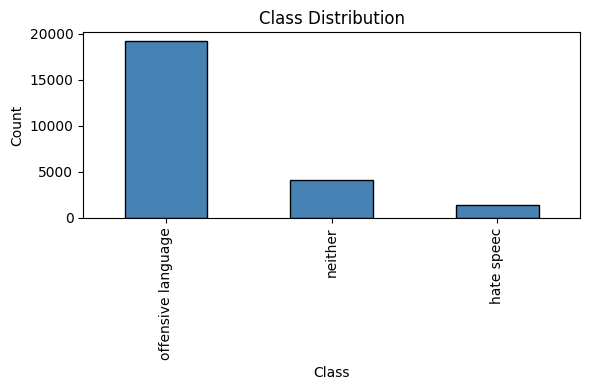

In [3]:
DATA_PATH = Path.cwd() / "Hate Speech Detection Dataset" / "hatevsoffensive_language.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Detect text and label columns
candidate_text_cols = ["tweet", "text", "comment", "sentence"]
candidate_label_cols = ["class", "label", "category"]
text_col = next((c for c in candidate_text_cols if c in df.columns), df.columns[0])
label_col = next((c for c in candidate_label_cols if c in df.columns), df.columns[-1])
print("Text column:", text_col)
print("Label column:", label_col)

# Map numeric labels to names if needed
label_map = None
if pd.api.types.is_numeric_dtype(df[label_col]):
    unique_labels = sorted(df[label_col].unique())
    if set(unique_labels) <= {0, 1, 2}:
        label_map = {0: "Hate Speech", 1: "Offensive Language", 2: "Neither"}
        df["label_name"] = df[label_col].map(label_map)
    else:
        df["label_name"] = df[label_col].astype(str)
else:
    df["label_name"] = df[label_col].astype(str)

print(df[[text_col, label_col]].head())

class_counts = df["label_name"].value_counts()
print("\nClass distribution:\n", class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. Text Preprocessing (Cleaning, Stopwords, Lemmatization)

- Lowercase text.
- Remove URLs, mentions, hashtags.
- Remove numbers and special characters.
- Remove stopwords.
- Lemmatize tokens.

In [4]:
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "we've": "we have", "they're": "they are",
    "they've": "they have", "that's": "that is", "what's": "what is",
    "there's": "there is", "let's": "let us"
}

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    text = text.lower()
    for c, e in CONTRACTIONS.items():
        text = text.replace(c, e)
    return text

def clean_text(text):
    text = expand_contractions(str(text))
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df[text_col].apply(clean_text)
print(df[[text_col, "clean_text"]].head(3))

                                                text  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   

                                          clean_text  
0  woman complain cleaning house amp man always t...  
1      boy dat coldtyga dwn bad cuffin dat hoe place  
2       dawg ever fuck bitch start cry confused shit  


## 5. Visualize Cleaned Text (Word Cloud and Top Words)

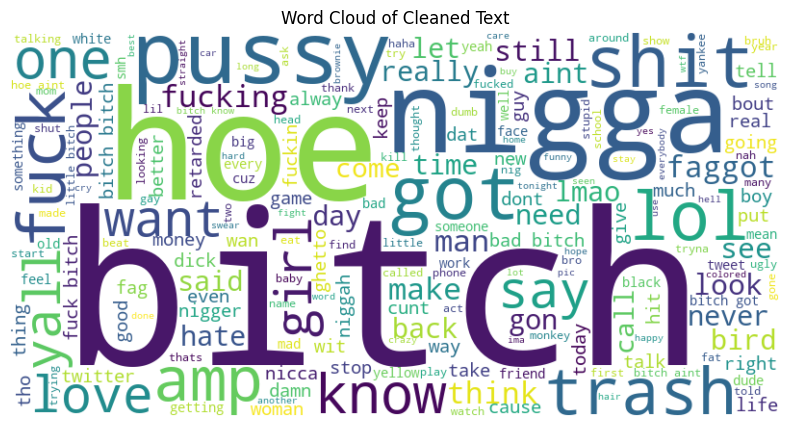

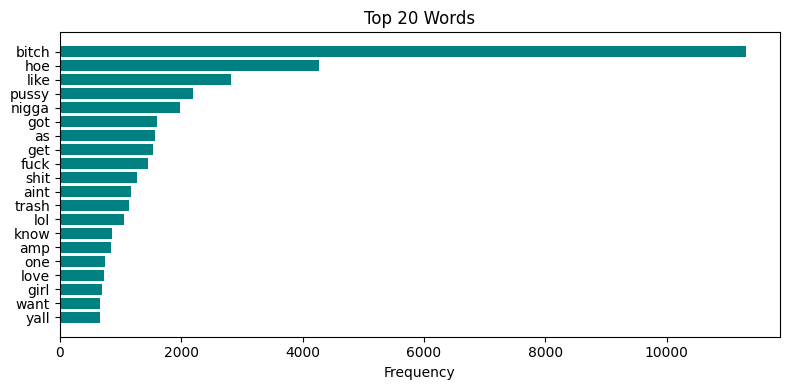

In [5]:
all_text = " ".join(df["clean_text"].astype(str))
wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Text")
plt.show()

top_words = Counter(all_text.split()).most_common(20)
words, counts = zip(*top_words)
plt.figure(figsize=(8, 4))
plt.barh(list(words)[::-1], list(counts)[::-1], color="teal")
plt.title("Top 20 Words")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Tokenization and Percentile Padding (80/20 Split)
Workflow matches the tutorial:
- Split before tokenization to avoid leakage.
- Fit tokenizer on training data only.
- Use 95th percentile length for padding to reduce outliers.

In [6]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["label_name"])
label_names = list(encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], y, test_size=0.2, random_state=SEED, stratify=y
 )
print("Train size:", len(X_train))
print("Test size:", len(X_test))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
 )
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)

MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

lengths = [len(s) for s in train_sequences]
p95 = int(np.percentile(lengths, 95))
MAX_LEN = min(100, max(10, p95))
print("Padding length:", MAX_LEN)

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
print("X_train_pad:", X_train_pad.shape)

Train size: 19826
Test size: 4957
Class weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}
Padding length: 13
X_train_pad: (19826, 13)


## 7. Model 1: Simple RNN (Trainable Embedding)
Baseline model from Week 9 to capture sequential patterns.

In [7]:
model_rnn = Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS, 100),
    SimpleRNN(64, activation="tanh"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(len(label_names), activation="softmax")
 ])

model_rnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
 )

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,739 (3.86 MB)

 Trainable params: 1,012,739 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

if "class_weights" not in globals():
    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weights = {int(c): float(w) for c, w in zip(np.unique(y_train), cw)}

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
 )

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6958 - loss: 0.7932 - val_accuracy: 0.7640 - val_loss: 0.6324
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8100 - loss: 0.4655 - val_accuracy: 0.7564 - val_loss: 0.5783
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8678 - loss: 0.3072 - val_accuracy: 0.7902 - val_loss: 0.5893
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9106 - loss: 0.2032 - val_accuracy: 0.8048 - val_loss: 0.6203
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9319 - loss: 0.1597 - val_accuracy: 0.7776 - val_loss: 0.7333


## 8. Model 2: LSTM (Trainable Embedding)
LSTM handles longer dependencies and reduces vanishing-gradient issues compared to Simple RNN.

In [9]:
model_lstm = Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS, 100),
    LSTM(128, activation="tanh", return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation="tanh"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(len(label_names), activation="softmax")
 ])

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
 )

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,011 (4.47 MB)

 Trainable params: 1,171,011 (4.47 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
if "class_weights" not in globals():
    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weights = {int(c): float(w) for c, w in zip(np.unique(y_train), cw)}

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
 )

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.7551 - loss: 0.7348 - val_accuracy: 0.7852 - val_loss: 0.6265
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.8263 - loss: 0.4379 - val_accuracy: 0.7832 - val_loss: 0.5520
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.8687 - loss: 0.3059 - val_accuracy: 0.7756 - val_loss: 0.6099
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8975 - loss: 0.2387 - val_accuracy: 0.7937 - val_loss: 0.5748
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9072 - loss: 0.2055 - val_accuracy: 0.6082 - val_loss: 1.0914


## 9. Model 3: LSTM with Pretrained Word2Vec (GloVe)

In [11]:
print("Loading pretrained embeddings...")
embedding_model = api.load("glove-wiki-gigaword-50")
EMBED_DIM = 50

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
coverage = found / vocab_size * 100
print(f"Embedding coverage: {coverage:.1f}%")

Loading pretrained embeddings...
Embedding coverage: 82.5%


In [12]:
model_w2v = Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(128, activation="tanh", return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation="tanh"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(len(label_names), activation="softmax")
 ])

model_w2v.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
 )

model_w2v.summary()

if "class_weights" not in globals():
    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    class_weights = {int(c): float(w) for c, w in zip(np.unique(y_train), cw)}

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
 )

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 13, 128)        │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,411 (2.46 MB)

 Trainable params: 145,411 (568.01 KB)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.6798 - loss: 0.7802 - val_accuracy: 0.7121 - val_loss: 0.7446
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.7617 - loss: 0.6119 - val_accuracy: 0.7771 - val_loss: 0.6224
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.7764 - loss: 0.5592 - val_accuracy: 0.7766 - val_loss: 0.5870


## 10. Evaluation: Accuracy, Confusion Matrix, Classification Report


 Simple RNN
Accuracy: 0.7543
                    precision    recall  f1-score   support

        hate speec       0.18      0.66      0.28       286
           neither       0.75      0.86      0.80       833
offensive language       0.96      0.74      0.83      3838

          accuracy                           0.75      4957
         macro avg       0.63      0.75      0.64      4957
      weighted avg       0.88      0.75      0.80      4957


 LSTM
Accuracy: 0.786
                    precision    recall  f1-score   support

        hate speec       0.21      0.67      0.32       286
           neither       0.76      0.88      0.82       833
offensive language       0.96      0.77      0.86      3838

          accuracy                           0.79      4957
         macro avg       0.65      0.77      0.67      4957
      weighted avg       0.89      0.79      0.82      4957


 LSTM + Word2Vec
Accuracy: 0.7075
                    precision    recall  f1-score   support

     

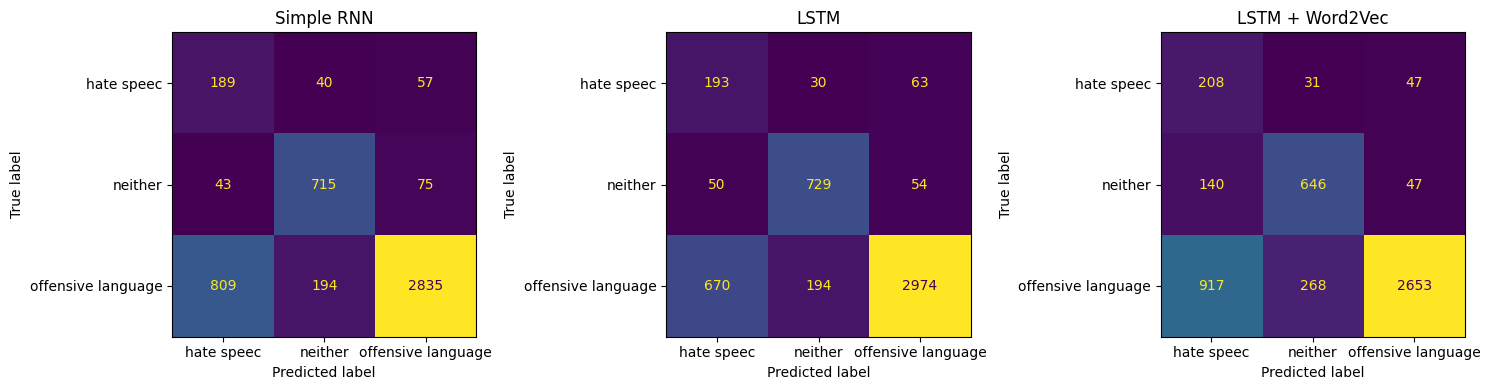

In [13]:
def evaluate_model(model, X, y, name):
    probs = model.predict(X, verbose=0)
    preds = probs.argmax(axis=1)
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds, average="macro", zero_division=0)
    rec = recall_score(y, preds, average="macro", zero_division=0)
    f1 = f1_score(y, preds, average="macro", zero_division=0)
    print("\n", name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y, preds, target_names=label_names, zero_division=0))
    return {
        "name": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "y_pred": preds
    }

results_rnn = evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN")
results_lstm = evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")
results_w2v = evaluate_model(model_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, [results_rnn, results_lstm, results_w2v]):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(res["name"])
plt.tight_layout()
plt.show()

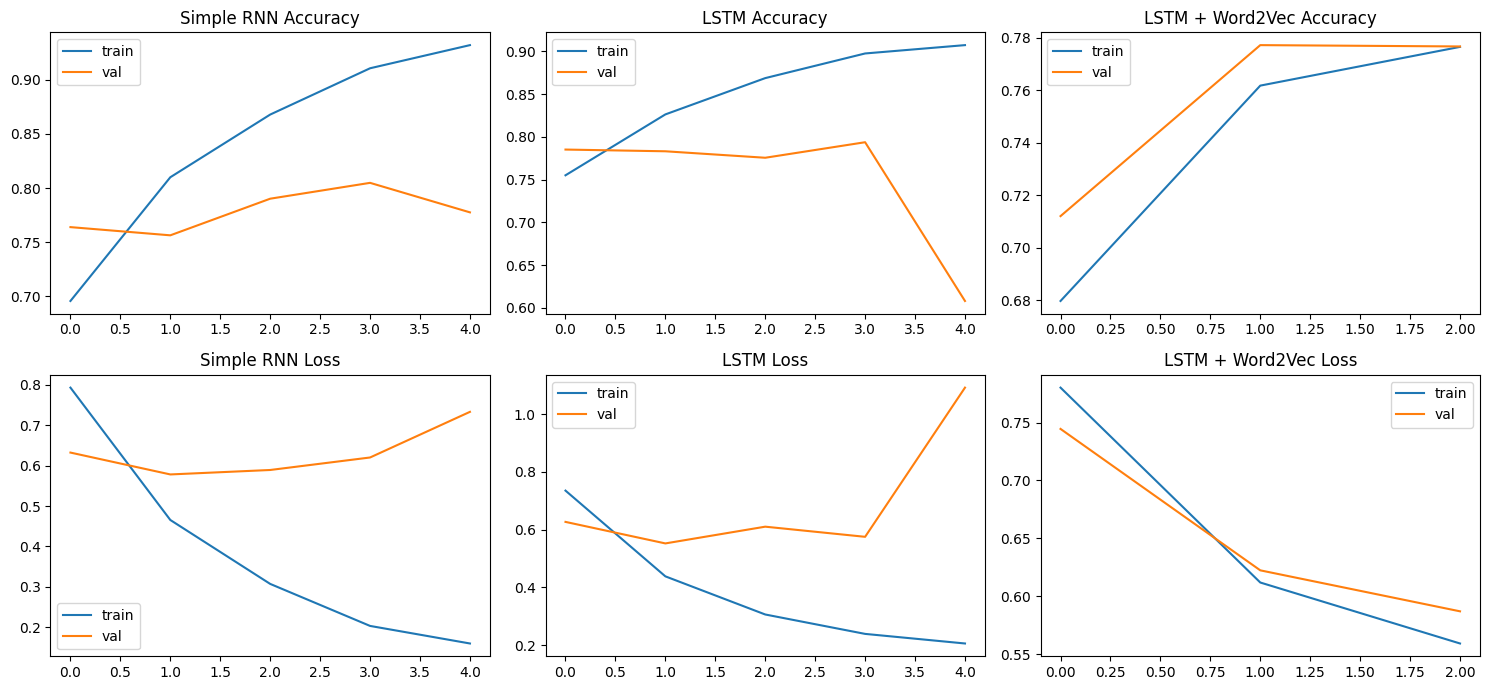

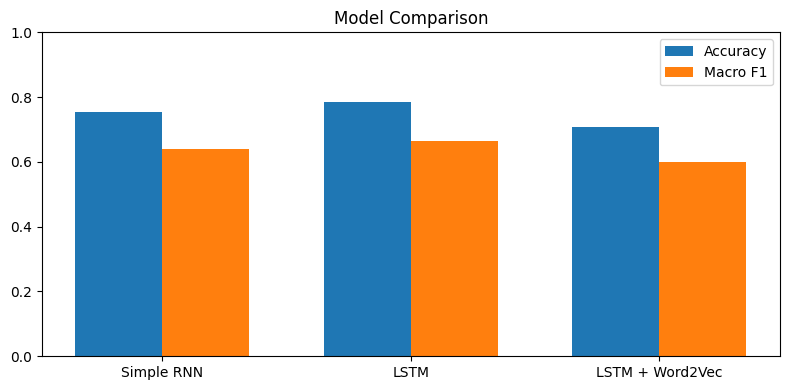

In [14]:
histories = [
    (history_rnn, "Simple RNN"),
    (history_lstm, "LSTM"),
    (history_w2v, "LSTM + Word2Vec")
 ]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, (hist, name) in enumerate(histories):
    axes[0, col].plot(hist.history["accuracy"], label="train")
    axes[0, col].plot(hist.history["val_accuracy"], label="val")
    axes[0, col].set_title(name + " Accuracy")
    axes[0, col].legend()
    axes[1, col].plot(hist.history["loss"], label="train")
    axes[1, col].plot(hist.history["val_loss"], label="val")
    axes[1, col].set_title(name + " Loss")
    axes[1, col].legend()
plt.tight_layout()
plt.show()

model_names = [results_rnn["name"], results_lstm["name"], results_w2v["name"]]
accuracies = [results_rnn["accuracy"], results_lstm["accuracy"], results_w2v["accuracy"]]
f1_scores = [results_rnn["f1"], results_lstm["f1"], results_w2v["f1"]]

x = np.arange(len(model_names))
width = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, accuracies, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1")
plt.xticks(x, model_names)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Error Analysis (Misclassified Examples)

In [15]:
best_results = max([results_rnn, results_lstm, results_w2v], key=lambda r: r["accuracy"])
best_preds = best_results["y_pred"]

mis_idx = np.where(best_preds != y_test)[0]
print("Best model:", best_results["name"])
print("Misclassified samples:", len(mis_idx))

for i in mis_idx[:3]:
    original_text = X_test.iloc[i]
    true_label = label_names[y_test[i]]
    pred_label = label_names[best_preds[i]]
    print("\nText:", original_text[:120])
    print("True:", true_label, "Pred:", pred_label)

print("\nPossible reasons:")
print("- Short or ambiguous text after cleaning")
print("- Overlap between offensive and hate categories")
print("- Out-of-vocabulary words")

Best model: LSTM
Misclassified samples: 1061

Text: ight nigga tonight burg mall bitch
True: offensive language Pred: hate speec

Text: full nigger
True: offensive language Pred: hate speec

Text: nigga send hate thru bitch
True: offensive language Pred: hate speec

Possible reasons:
- Short or ambiguous text after cleaning
- Overlap between offensive and hate categories
- Out-of-vocabulary words


## 12. Real-Time Prediction GUI (Gradio)

In [16]:
def predict_text(text, model_choice):
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    model_map = {
        "Simple RNN": model_rnn,
        "LSTM": model_lstm,
        "LSTM + Word2Vec": model_w2v
    }
    model = model_map.get(model_choice, model_lstm)
    pred = model.predict(pad, verbose=0).argmax(axis=1)[0]
    return label_names[pred]

with gr.Blocks() as demo:
    gr.Markdown("# Hate Speech Text Classification")
    gr.Markdown("Select a model and enter a text sample.")
    with gr.Row():
        text_in = gr.Textbox(lines=3, label="Input text")
        model_choice = gr.Radio(["Simple RNN", "LSTM", "LSTM + Word2Vec"], value="LSTM", label="Model")
    out = gr.Textbox(label="Prediction")
    btn = gr.Button("Predict")
    btn.click(fn=predict_text, inputs=[text_in, model_choice], outputs=out)

demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
